In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import sys
import math
from jaxtyping import Float, Array, PRNGKeyArray

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "..")
Tensor = Float[Array, "..."]

In [2]:
plt.rcParams["svg.fonttype"] = "none"
## Set up LaTeX fonts
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 14,
    }
)

# Defining the problem

In [3]:
from ctt.bases import make_canonical_polynomials, make_fourier, make_legendre_polynomials, make_chebyshev_polynomials

d = 4
n_features = 2
basis = make_canonical_polynomials(dim=n_features)
# basis = make_legendre_polynomials(dim=n_features)
# basis = make_chebyshev_polynomials(dim=n_features)
# basis = make_fourier(n_features)
# basis = lambda x: jnp.asarray([1., jax.nn.leaky_relu(x)])
key = random.PRNGKey(42)

In [4]:
def lift(x: Float[Array, "d"]) -> Float[Array, "m"]:
    # return jnp.hstack((jnp.zeros((1,)), x))
    return x

def retraction(x: Float[Array, "m"]) -> Float[Array, "o"]:
    return jnp.asarray((x[0],))

d_lift = jax.eval_shape(lift, jax.ShapeDtypeStruct((d,), dtype=float)).shape[0]
bases = [basis]*d_lift

In [5]:
from ctt.model import _eval_bases

def _eval_tensor(tensor: Tensor, x: Float[Array, "d"]) -> Float[Array, "d"]:
    features = _eval_bases(bases, x)
    y = tensor # (d, m, ..., m)
    for i in range(len(features)):
        y = jnp.einsum("di...,i->d...", y, features[i])
    return y

def _eval_ct(tensors: list[Tensor], x: Float[Array, "d"]) -> Float[Array, "d_o"]:
    def _body_fn(i: int, val: Float[Array, "d"]) -> Float[Array, "d"]:
        control = jax.lax.switch(i, [lambda u=u: u for u in tensors])
        return val + _eval_tensor(control, val)

    x = lift(x)
    val = jax.lax.fori_loop(0, len(tensors), _body_fn, x)
    val = retraction(val)
    return val

In [6]:
key, sample_key = random.split(key)
Sigma = random.normal(key=sample_key, shape=(d, d))
Sigma = Sigma @ Sigma.T / d

TARGET_FUNCTION = "hyperbolic"

@jax.jit
def target(x: Float[Array, "d"]) -> Float[Array, "m"]:
    if TARGET_FUNCTION == "standard-gaussian":
        val = jnp.exp(-jnp.sum(x**2) / 2)
    elif TARGET_FUNCTION == "heaviside":
        val = jnp.prod((x >= 0.0) * 1.0)
    elif TARGET_FUNCTION == "gaussian":
        val = jax.scipy.stats.multivariate_normal.pdf(
            x=x, mean=jnp.zeros_like(x), cov=Sigma
        )
    elif TARGET_FUNCTION == "henon-heiles":
        val = (
            0.5 * jnp.sum(x**2)
            + 0.2 * jnp.sum(x[:-1] * x[1:] ** 2 - x[:-1] ** 3)
            + 0.2**2 / 16 * jnp.sum((x[:-1] ** 2 + x[1:] ** 2) ** 2)
        )
    elif TARGET_FUNCTION == "bivariate":
        val = jnp.mean((x[::2] + x[1::2]) ** 2)
    elif TARGET_FUNCTION == "mixture":
        val = jnp.sin(x[0] + x[2])*jnp.exp(x[3])*x[4] + jnp.sin(x[1]*x[2])*x[4]
    elif TARGET_FUNCTION == "hyperbolic":
        val = 1./(1.+jnp.prod(x))
    return jnp.atleast_1d(val)

# Learning

In [7]:
key, train_key, val_key = random.split(key, 3)

domain = (0., 1.)
N_train = 1_000_000
X_train = random.uniform(key=train_key, shape=(N_train, d), minval=domain[0], maxval=domain[1])
# X_train = random.normal(key=train_key, shape=(N_train, d))
y_train = jax.vmap(target)(X_train)

N_val = 2000
X_val = random.uniform(key=val_key, shape=(N_val, d), minval=domain[0], maxval=domain[1])
# X_val = random.normal(key=val_key, shape=(N_val, d))
y_val = jax.vmap(target)(X_val)

num_steps = 2

In [8]:
def dataloader(arrays: list, batch_size: int, *, key: PRNGKeyArray):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = random.permutation(key, indices)
        (key,) = random.split(key, 1)
        start = 0
        end = batch_size
        while end <= dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

In [9]:
import optax

@jax.jit
def compute_loss(tensors: list[Tensor],
                 x: Float[Array, "B d"],
                 y: Float[Array, "B d_o"]) -> float:
    y_pred = jax.vmap(_eval_ct, in_axes=(None, 0))(tensors, x)
    loss = jnp.mean(optax.l2_loss(y_pred, y))
    return 0.5*loss

@jax.jit
def grad_loss(y_hat: Float[Array, "B d_o"], y: Float[Array, "B d_o"]) -> Float[Array, "B d_o"]:
    # return y_hat - y
    return (y_hat - y) / y_hat.shape[0]

In [10]:
import jax.flatten_util
import operator
import lineax
from functools import partial

def natural_gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                             val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                             optimizer: optax.GradientTransformation,
                             params: list[Tensor],
                             opt_steps: int,
                             training_key: PRNGKeyArray,
                             batch_size: int = 64,
                             backtracking: bool = False,
                             damping_coeff: float = None) -> tuple[list[Tensor], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []

    def tree_mvp_dampen(mvp, lmbda=0.1):
        dampen_fcn = lambda mvp_, v_: mvp_ + lmbda * v_
        damp_mvp = lambda v: jax.tree.map(dampen_fcn, mvp(v), v)
        return damp_mvp

    def _natural_grad(tensors: list[Tensor],
                      x: Float[Array, "B d"],
                      grads: list[Tensor],
                      y: Float[Array, "B d_o"]) -> tuple[list[Tensor], dict]:
        # f = lambda w: jax.vmap(_eval_ct, in_axes=(None,0))(w, x).ravel() / jnp.sqrt(x.shape[0])
        # fvp = lambda v: jax.vjp(f, tensors)[1](jax.jvp(f, (tensors,), (v,))[1])[0]
        # if damping_coeff is not None:
        #     fvp = tree_mvp_dampen(fvp, lmbda=damping_coeff)
        # ngrad, _ = jax.scipy.sparse.linalg.cg(fvp, grads, maxiter=40, tol=1e-10)
        # # op = lineax.FunctionLinearOperator(fvp, jax.eval_shape(lambda: grads), tags=[lineax.symmetric_tag, lineax.positive_semidefinite_tag])
        # # solution = lineax.linear_solve(op, grads, solver=lineax.AutoLinearSolver(well_posed=True))
        # # ngrad = solution.value
        # # r = jax.tree.map(operator.sub, grads, fvp(ngrad))
        # # r_norm = sum(jax.tree.leaves(jax.tree.map(jnp.vdot, r, r)))
        # # jax.debug.print("Residual: {r}", r=jnp.sqrt(r_norm))
        # return ngrad

        # solving the normal equation G @ dir = grad
        # def _block_projection(grad: Tensor, k: int) -> Tensor:
        #     tt = tensors[k]
        #     def _f(w: Tensor, *args: None) -> Float[Array, "N"]:
        #         params = tensors[:k] + [w] + tensors[k+1:]
        #         return jax.vmap(_eval_ct, in_axes=(None, 0))(params, x).ravel()
        #     fvp = lambda v: jax.vjp(_f, tt)[1](jax.jvp(_f, (tt,), (v,))[1])[0] / x.shape[0]
        #     if damping_coeff is not None:
        #         fvp = tree_mvp_dampen(fvp, lmbda=damping_coeff)
        #     ngrad, _ = jax.scipy.sparse.linalg.cg(fvp, grad, maxiter=40, tol=1e-10)
        #     # op = lineax.FunctionLinearOperator(fvp, jax.eval_shape(lambda: grad), tags=[lineax.symmetric_tag, lineax.positive_semidefinite_tag])
        #     # solution = lineax.linear_solve(op, grad, solver=lineax.AutoLinearSolver(well_posed=True))
        #     # ngrad = solution.value
        #     return ngrad
        
        # solving the least-squares problem ||du/dtheta_k @ dir - grad L||
        y_pred = jax.vmap(_eval_ct, in_axes=(None, 0))(tensors, x)
        grad_losses = grad_loss(y_pred, y)
        def _block_projection(grad: Tensor, k: int) -> tuple[Tensor, Float[Array, "m"]]:
            tensor = tensors[k]
            def _f(w: Tensor, *args: None) -> Float[Array, "B d_o"]:
                params = tensors[:k] + [w] + tensors[k+1:]
                return jax.vmap(_eval_ct, in_axes=(None, 0))(params, x)
            
            J = jax.jacfwd(_f)(tensor)
            J = jnp.reshape(J, (J.shape[0]*J.shape[1],-1)) # (B*d_o, n_params)
            ngrad, resid, rank, s = jnp.linalg.lstsq(J, grad_losses.ravel(), rcond=damping_coeff)
            # p = s / jnp.linalg.norm(s, ord=1)
            # jax.debug.print("Rnage of singular value (k={k}): [{a}, {b}], rank={rank}, effective rank={eff_rank}",
            #                 k=k,
            #                 a=jnp.min(s),
            #                 b=jnp.max(s),
            #                 rank=rank,
            #                 eff_rank=jnp.exp(-jnp.sum(p*jnp.log(p))))
            ngrad = jnp.reshape(ngrad, tensor.shape)
            return ngrad, s
        
        ngrads, s = zip(*[_block_projection(grads[k], k) for k in range(len(tensors))])
        ngrads = list(ngrads)
        return ngrads, {"singular_values": s}

    @jax.jit
    def step(tensors: list[Tensor],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"]):
        loss, grads = jax.value_and_grad(compute_loss)(tensors, x, y)
        ngrad, info = _natural_grad(tensors, x, grads, y)
        if backtracking:
            updates, opt_state = optimizer.update(ngrad, opt_state, tensors, value=loss, grad=ngrad, value_fn=lambda p: compute_loss(p, x,y))
        else:
            updates, opt_state = optimizer.update(ngrad, opt_state, tensors)
        params = optax.apply_updates(tensors, updates)
        return params, opt_state, loss, info

    learning_rates = []
    infos = []
    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, opt_state, l2_error, info = step(params, 
                                                 opt_state, 
                                                 x,
                                                 y)
        val_loss = compute_loss(params, X_val, y_val)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        infos.append(info)
        if backtracking:
            learning_rates.append(opt_state[1].learning_rate)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses), learning_rates, infos

def gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                    val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                    optimizer: optax.GradientTransformation,
                    params: list[Tensor],
                    opt_steps: int,
                    training_key: PRNGKeyArray,
                    batch_size: int = 64,
                    backtracking: bool = False) -> tuple[list[Tensor], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []
    
    @jax.jit
    def step(tensors: list[Tensor],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"]):
        loss, grads = jax.value_and_grad(compute_loss)(tensors, x, y)
        if backtracking:
            updates, opt_state = optimizer.update(grads, opt_state, tensors, value=loss, grad=grads, value_fn=lambda p: compute_loss(p, x,y))
        else:
            updates, opt_state = optimizer.update(grads, opt_state, tensors)
        params = optax.apply_updates(tensors, updates)
        return params, opt_state, loss

    learning_rates = []
    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, opt_state, l2_error = step(params, 
                                            opt_state, 
                                            x,
                                            y)
        val_loss = compute_loss(params, X_val, y_val)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        if backtracking:
            if len(opt_state) > 1 and hasattr(opt_state[1], "learning_rate"):
                lr = getattr(opt_state[1], "learning_rate")
                learning_rates.append(lr)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses), learning_rates

In [11]:
key, *control_keys = random.split(key, num_steps+1)
key, training_key = random.split(key)

init_controls = [
    0.01*random.normal(key=control_key, shape=(d_lift,) + (n_features,)*d_lift)
    for control_key in control_keys
]
zero_init_controls = [
    jnp.zeros((d_lift,) + (n_features,)*d_lift)
    for _ in range(num_steps)
]
# init_controls = list(map(left_orth, init_controls))
print(list(map(jnp.linalg.norm, init_controls)))

[Array(0.08359788, dtype=float64), Array(0.08490121, dtype=float64)]


## Natural gradient descent

In [21]:
optimizer = optax.chain(
    optax.sgd(learning_rate=1.),
    # optax.scale_by_backtracking_linesearch(max_backtracking_steps=20)
    optax.scale_by_zoom_linesearch(max_linesearch_steps=20, initial_guess_strategy="one")
)

params_ng, (train_losses_ng, val_losses_ng), learning_rates_ng, infos = natural_gradient_descent(train_dataset=(X_train, y_train),
                                                                              val_dataset=(X_val, y_val),
                                                                              optimizer=optimizer,
                                                                              params=init_controls,
                                                                              opt_steps=10_000,
                                                                              training_key=training_key,
                                                                              batch_size=128,
                                                                              backtracking=True,
                                                                              damping_coeff=1e-8)

Iter 0 | Loss: 8.250e-02 | Val loss: 8.109e-02
Iter 5 | Loss: 7.198e-02 | Val loss: 6.875e-02
Iter 10 | Loss: 5.523e-02 | Val loss: 5.867e-02
Iter 15 | Loss: 5.126e-02 | Val loss: 5.010e-02
Iter 20 | Loss: 4.263e-02 | Val loss: 4.281e-02
Iter 25 | Loss: 3.819e-02 | Val loss: 3.656e-02
Iter 30 | Loss: 2.892e-02 | Val loss: 3.122e-02
Iter 35 | Loss: 2.210e-02 | Val loss: 2.665e-02
Iter 40 | Loss: 2.169e-02 | Val loss: 2.276e-02
Iter 45 | Loss: 1.745e-02 | Val loss: 1.944e-02
Iter 50 | Loss: 1.637e-02 | Val loss: 1.662e-02
Iter 55 | Loss: 1.266e-02 | Val loss: 1.420e-02
Iter 60 | Loss: 1.171e-02 | Val loss: 1.214e-02
Iter 65 | Loss: 9.515e-03 | Val loss: 1.038e-02
Iter 70 | Loss: 9.138e-03 | Val loss: 8.871e-03
Iter 75 | Loss: 6.827e-03 | Val loss: 7.583e-03
Iter 80 | Loss: 6.378e-03 | Val loss: 6.483e-03
Iter 85 | Loss: 5.036e-03 | Val loss: 5.539e-03
Iter 90 | Loss: 4.118e-03 | Val loss: 4.734e-03
Iter 95 | Loss: 3.710e-03 | Val loss: 4.046e-03
Iter 100 | Loss: 3.555e-03 | Val loss: 3.4

## Adam

In [13]:
optimizer = optax.chain(
    optax.adam(learning_rate=1.),
    # optax.scale_by_backtracking_linesearch(max_backtracking_steps=20)
    optax.scale_by_zoom_linesearch(max_linesearch_steps=20, initial_guess_strategy="keep")
)

params_gd, (train_losses_gd, val_losses_gd), learning_rates_gd = gradient_descent(train_dataset=(X_train, y_train),
                                                                              val_dataset=(X_val, y_val),
                                                                              optimizer=optimizer,
                                                                              params=init_controls,
                                                                              opt_steps=20_000,
                                                                              training_key=training_key,
                                                                              batch_size=128,
                                                                              backtracking=True)

Iter 0 | Loss: 8.250e-02 | Val loss: 4.824e-02
Iter 5 | Loss: 1.002e-02 | Val loss: 8.551e-03
Iter 10 | Loss: 5.302e-03 | Val loss: 3.421e-03
Iter 15 | Loss: 2.620e-03 | Val loss: 2.529e-03
Iter 20 | Loss: 1.931e-03 | Val loss: 2.300e-03
Iter 25 | Loss: 2.359e-03 | Val loss: 1.962e-03
Iter 30 | Loss: 1.543e-03 | Val loss: 1.100e-03
Iter 35 | Loss: 7.765e-04 | Val loss: 7.673e-04
Iter 40 | Loss: 5.727e-04 | Val loss: 6.360e-04
Iter 45 | Loss: 7.739e-04 | Val loss: 6.214e-04
Iter 50 | Loss: 5.530e-04 | Val loss: 6.002e-04
Iter 55 | Loss: 4.416e-04 | Val loss: 5.161e-04
Iter 60 | Loss: 4.483e-04 | Val loss: 4.496e-04
Iter 65 | Loss: 4.618e-04 | Val loss: 3.972e-04
Iter 70 | Loss: 5.126e-04 | Val loss: 3.923e-04
Iter 75 | Loss: 4.397e-04 | Val loss: 3.470e-04
Iter 80 | Loss: 3.901e-04 | Val loss: 2.383e-04
Iter 85 | Loss: 1.615e-04 | Val loss: 1.727e-04
Iter 90 | Loss: 1.207e-04 | Val loss: 1.555e-04
Iter 95 | Loss: 1.509e-04 | Val loss: 1.520e-04
Iter 100 | Loss: 1.101e-04 | Val loss: 1.4

## L-BFGS

In [18]:
optimizer = optax.lbfgs(memory_size=10,
                        scale_init_precond=False,
                        linesearch=optax.scale_by_zoom_linesearch(max_linesearch_steps=20,
                                                                  increase_factor=1.5,
                                                                  initial_guess_strategy="one"))

params_lbfgs, (train_losses_lbfgs, val_losses_lbfgs), learning_rates_lbfgs = gradient_descent(train_dataset=(X_train, y_train),
                                                                              val_dataset=(X_val, y_val),
                                                                              optimizer=optimizer,
                                                                              params=init_controls,
                                                                              opt_steps=20_000,
                                                                              training_key=training_key,
                                                                              batch_size=128,
                                                                              backtracking=True)

Iter 0 | Loss: 8.250e-02 | Val loss: 3.422e-02
Iter 5 | Loss: 1.619e-03 | Val loss: 1.234e-03
Iter 10 | Loss: 6.407e-04 | Val loss: 6.464e-04
Iter 15 | Loss: 6.160e-04 | Val loss: 5.693e-04
Iter 20 | Loss: 3.679e-04 | Val loss: 2.774e-04
Iter 25 | Loss: 2.547e-04 | Val loss: 2.178e-04
Iter 30 | Loss: 3.116e-04 | Val loss: 2.067e-04
Iter 35 | Loss: 2.081e-04 | Val loss: 1.615e-04
Iter 40 | Loss: 1.191e-04 | Val loss: 1.205e-04
Iter 45 | Loss: 1.073e-04 | Val loss: 1.139e-04
Iter 50 | Loss: 1.003e-04 | Val loss: 8.701e-05
Iter 55 | Loss: 8.556e-05 | Val loss: 8.373e-05
Iter 60 | Loss: 1.225e-04 | Val loss: 8.118e-05
Iter 65 | Loss: 9.051e-05 | Val loss: 8.084e-05
Iter 70 | Loss: 1.025e-04 | Val loss: 8.180e-05
Iter 75 | Loss: 8.726e-05 | Val loss: 7.878e-05
Iter 80 | Loss: 1.029e-04 | Val loss: 8.566e-05
Iter 85 | Loss: 9.911e-05 | Val loss: 7.288e-05
Iter 90 | Loss: 5.951e-05 | Val loss: 7.205e-05
Iter 95 | Loss: 5.550e-05 | Val loss: 7.422e-05
Iter 100 | Loss: 7.362e-05 | Val loss: 7.2

## BFGS

In [15]:
import jaxopt

solver = jaxopt.BFGS(fun=compute_loss)
params = init_controls
X, y = X_train[:4096], y_train[:4096]
state = solver.init_state(params, x=X, y=y)
val_losses_bfgs = []

for k in range(10_000):
    params, state = solver.update(params, state, x=X, y=y)
    val_loss = compute_loss(params, x=X_val, y=y_val)
    val_losses_bfgs.append(val_loss)
    if k % 5 == 0:
        print(f"Iter {k} | Loss: {state.value:.3e} | Val loss: {val_loss:.3e}")

Iter 0 | Loss: 3.562e-02 | Val loss: 3.465e-02
Iter 5 | Loss: 1.252e-03 | Val loss: 1.185e-03
Iter 10 | Loss: 7.070e-04 | Val loss: 6.151e-04
Iter 15 | Loss: 3.503e-04 | Val loss: 3.351e-04
Iter 20 | Loss: 8.386e-05 | Val loss: 8.293e-05
Iter 25 | Loss: 7.877e-05 | Val loss: 7.771e-05
Iter 30 | Loss: 6.947e-05 | Val loss: 6.686e-05
Iter 35 | Loss: 6.085e-05 | Val loss: 5.770e-05
Iter 40 | Loss: 5.545e-05 | Val loss: 5.260e-05
Iter 45 | Loss: 2.782e-05 | Val loss: 2.738e-05
Iter 50 | Loss: 2.363e-05 | Val loss: 2.324e-05
Iter 55 | Loss: 2.257e-05 | Val loss: 2.200e-05
Iter 60 | Loss: 2.097e-05 | Val loss: 1.988e-05
Iter 65 | Loss: 1.930e-05 | Val loss: 1.804e-05
Iter 70 | Loss: 1.623e-05 | Val loss: 1.473e-05
Iter 75 | Loss: 1.612e-05 | Val loss: 1.448e-05
Iter 80 | Loss: 1.385e-05 | Val loss: 1.127e-05
Iter 85 | Loss: 1.156e-05 | Val loss: 9.754e-06
Iter 90 | Loss: 1.121e-05 | Val loss: 9.385e-06
Iter 95 | Loss: 1.041e-05 | Val loss: 8.728e-06
Iter 100 | Loss: 1.024e-05 | Val loss: 8.6

## Plotting the error

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


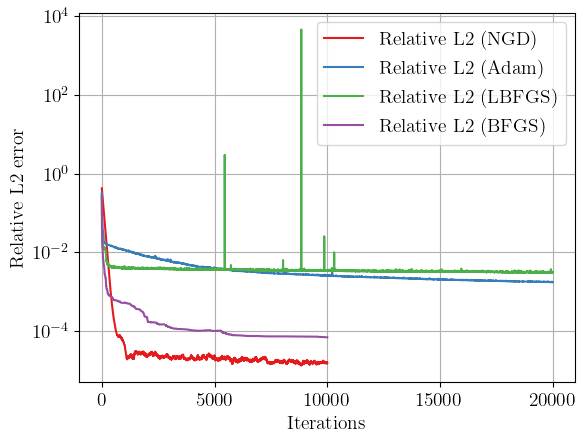

In [23]:
from matplotlib import colormaps
from cycler import cycler

y_val_norm = jnp.mean(optax.l2_loss(jnp.zeros_like(y_val), y_val))

# plot NGD losses
val_losses_ng = jnp.asarray(val_losses_ng)
val_losses_gd = jnp.asarray(val_losses_gd)
val_losses_lbfgs = jnp.asarray(val_losses_lbfgs)
val_losses_bfgs = jnp.asarray(val_losses_bfgs)

plt.rcParams.update({"axes.prop_cycle": cycler(color=colormaps["Set1"].colors)})

plt.semilogy(jnp.arange(len(val_losses_ng)),
             jnp.sqrt(val_losses_ng/y_val_norm),
             label="Relative L2 (NGD)")
plt.semilogy(jnp.arange(len(val_losses_gd)),
             jnp.sqrt(val_losses_gd/y_val_norm),
             label="Relative L2 (Adam)")
plt.semilogy(jnp.arange(len(val_losses_lbfgs)),
             jnp.sqrt(val_losses_lbfgs/y_val_norm),
             label="Relative L2 (LBFGS)")
plt.semilogy(jnp.arange(len(val_losses_bfgs)),
             jnp.sqrt(val_losses_bfgs/y_val_norm),
             label="Relative L2 (BFGS)")

plt.grid()
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Relative L2 error")
plt.savefig("error.eps", format="eps", dpi=1200)
# plt.clf()
# plt.cla()

# # plot learning rates
# plt.semilogy(learning_rates_ng)
# plt.grid()
# plt.xlabel("Iterations")
# plt.ylabel("Learning rate")

## Evolution of the singular values

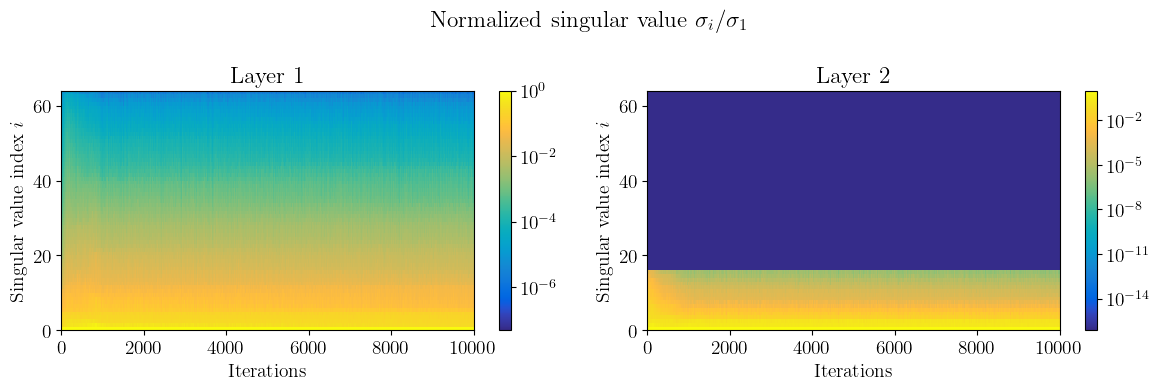

In [24]:
from matplotlib.colors import LinearSegmentedColormap

cm_data = [[0.2081, 0.1663, 0.5292], [0.2116238095, 0.1897809524, 0.5776761905], 
 [0.212252381, 0.2137714286, 0.6269714286], [0.2081, 0.2386, 0.6770857143], 
 [0.1959047619, 0.2644571429, 0.7279], [0.1707285714, 0.2919380952, 
  0.779247619], [0.1252714286, 0.3242428571, 0.8302714286], 
 [0.0591333333, 0.3598333333, 0.8683333333], [0.0116952381, 0.3875095238, 
  0.8819571429], [0.0059571429, 0.4086142857, 0.8828428571], 
 [0.0165142857, 0.4266, 0.8786333333], [0.032852381, 0.4430428571, 
  0.8719571429], [0.0498142857, 0.4585714286, 0.8640571429], 
 [0.0629333333, 0.4736904762, 0.8554380952], [0.0722666667, 0.4886666667, 
  0.8467], [0.0779428571, 0.5039857143, 0.8383714286], 
 [0.079347619, 0.5200238095, 0.8311809524], [0.0749428571, 0.5375428571, 
  0.8262714286], [0.0640571429, 0.5569857143, 0.8239571429], 
 [0.0487714286, 0.5772238095, 0.8228285714], [0.0343428571, 0.5965809524, 
  0.819852381], [0.0265, 0.6137, 0.8135], [0.0238904762, 0.6286619048, 
  0.8037619048], [0.0230904762, 0.6417857143, 0.7912666667], 
 [0.0227714286, 0.6534857143, 0.7767571429], [0.0266619048, 0.6641952381, 
  0.7607190476], [0.0383714286, 0.6742714286, 0.743552381], 
 [0.0589714286, 0.6837571429, 0.7253857143], 
 [0.0843, 0.6928333333, 0.7061666667], [0.1132952381, 0.7015, 0.6858571429], 
 [0.1452714286, 0.7097571429, 0.6646285714], [0.1801333333, 0.7176571429, 
  0.6424333333], [0.2178285714, 0.7250428571, 0.6192619048], 
 [0.2586428571, 0.7317142857, 0.5954285714], [0.3021714286, 0.7376047619, 
  0.5711857143], [0.3481666667, 0.7424333333, 0.5472666667], 
 [0.3952571429, 0.7459, 0.5244428571], [0.4420095238, 0.7480809524, 
  0.5033142857], [0.4871238095, 0.7490619048, 0.4839761905], 
 [0.5300285714, 0.7491142857, 0.4661142857], [0.5708571429, 0.7485190476, 
  0.4493904762], [0.609852381, 0.7473142857, 0.4336857143], 
 [0.6473, 0.7456, 0.4188], [0.6834190476, 0.7434761905, 0.4044333333], 
 [0.7184095238, 0.7411333333, 0.3904761905], 
 [0.7524857143, 0.7384, 0.3768142857], [0.7858428571, 0.7355666667, 
  0.3632714286], [0.8185047619, 0.7327333333, 0.3497904762], 
 [0.8506571429, 0.7299, 0.3360285714], [0.8824333333, 0.7274333333, 0.3217], 
 [0.9139333333, 0.7257857143, 0.3062761905], [0.9449571429, 0.7261142857, 
  0.2886428571], [0.9738952381, 0.7313952381, 0.266647619], 
 [0.9937714286, 0.7454571429, 0.240347619], [0.9990428571, 0.7653142857, 
  0.2164142857], [0.9955333333, 0.7860571429, 0.196652381], 
 [0.988, 0.8066, 0.1793666667], [0.9788571429, 0.8271428571, 0.1633142857], 
 [0.9697, 0.8481380952, 0.147452381], [0.9625857143, 0.8705142857, 0.1309], 
 [0.9588714286, 0.8949, 0.1132428571], [0.9598238095, 0.9218333333, 
  0.0948380952], [0.9661, 0.9514428571, 0.0755333333], 
 [0.9763, 0.9831, 0.0538]]

parula_map = LinearSegmentedColormap.from_list('parula', cm_data)

singular_values = [infos[k]["singular_values"] for k in range(len(infos))]
singular_values = list(zip(*singular_values))
singular_values = list(map(jnp.stack, singular_values))

nrows = math.ceil(num_steps / 2)
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(12, 4*nrows))

for k in range(num_steps):
    ax = axes.flat[k]
    sv = singular_values[k]
    normalised_sv = sv / sv[:, :1]
    c = ax.pcolormesh(normalised_sv.T, norm="log", cmap=parula_map)
    ax.set_title(f"Layer {k+1}")
    ax.set_ylabel("Singular value index $i$")
    ax.set_xlabel("Iterations")
    fig.colorbar(c, ax=ax)
fig.suptitle("Normalized singular value $\sigma_i/\sigma_1$")
fig.tight_layout()
## access each axes object via axs.flat
for ax in axes.flat:
    ## check if something was plotted 
    if not bool(ax.has_data()):
        fig.delaxes(ax) ## delete if nothing is plotted in the axes obj


In [ ]:
jnp.save("full_ngd.npy", jnp.sqrt(val_losses_ng/y_val_norm))
jnp.save("full_adam.npy", jnp.sqrt(val_losses_gd/y_val_norm))